## Feature Selection 
## Information gain - mutual information in classification problem statements 

## Mutual Information in classificaiton 

Mutual information for discrete target variables

Mutual informaton between two random variable is a non-negative value, which measures the dependancy between the variables. It is equal to zero if and only if two random variables are independent and higher values mean higher dependancy. 


The function relies on non parametric methods based on entropy estimation from k-nearest neighbors distances. 

Inshort 

A quantity called mutual information measures the amount of information one can obtain from from one random variable given another. 

The mutual information between two random variables X and Y can be stated formally as follow: 

I(X;Y) = H(X) - H(X|Y) is mutual information for X and Y. H(X) is the entropy for X and H(X|Y) is the conditional entropy for X given Y. The results has the units of bits. 

Eğer 
𝑋
X ve 
𝑌
Y bağımsızsa, birbirleri hakkında hiçbir şey söylemezler → 
𝐼
(
𝑋
;
𝑌
)
=
0
I(X;Y)=0.

Eğer tamamen bağımlılarsa (örneğin 
𝑌
Y, 
𝑋
X’in aynısıysa), o zaman MI maksimum olur.

In [10]:
import pandas as pd 
df=pd.read_csv('https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv')
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [12]:
df["Wine"].unique()

array([1, 2, 3], dtype=int64)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [16]:
### Train test split to avoid overfitting
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(labels=['Wine'], axis=1),
    df['Wine'],
    test_size=0.3,
    random_state=0)

In [18]:
from sklearn.feature_selection import mutual_info_classif
mutual_info = mutual_info_classif(X_train, y_train)
mutual_info

array([0.41016493, 0.30192951, 0.17911446, 0.26646011, 0.19382458,
       0.47754579, 0.70857499, 0.11906144, 0.27551874, 0.61828882,
       0.56994826, 0.54978498, 0.53958733])

X'teki features ile target y değerleri ile ilişkisini ölçüyor 

Yüksek değer → feature, hedef hakkında çok bilgi veriyor.

Düşük/0’a yakın değer → feature, hedefi tahmin etmeye katkı sağlamıyor.

I(X;Y)=x,y∑​p(x,y)logp(x)p(y)/p(x,y)​

𝑝
(
𝑥
)
p(x): X’in değerlerinin olasılık dağılımı (marginal distribution).

𝑝
(
𝑦
)
p(y): Y’nin değerlerinin dağılımı.

𝑝
(
𝑥
,
𝑦
)
p(x,y): X ve Y’nin birlikte görülme olasılıkları (joint distribution).

In [27]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

Flavanoids              0.708575
Color.int               0.618289
Hue                     0.569948
OD                      0.549785
Proline                 0.539587
Phenols                 0.477546
Alcohol                 0.410165
Malic.acid              0.301930
Proanth                 0.275519
Acl                     0.266460
Mg                      0.193825
Ash                     0.179114
Nonflavanoid.phenols    0.119061
dtype: float64

<Axes: >

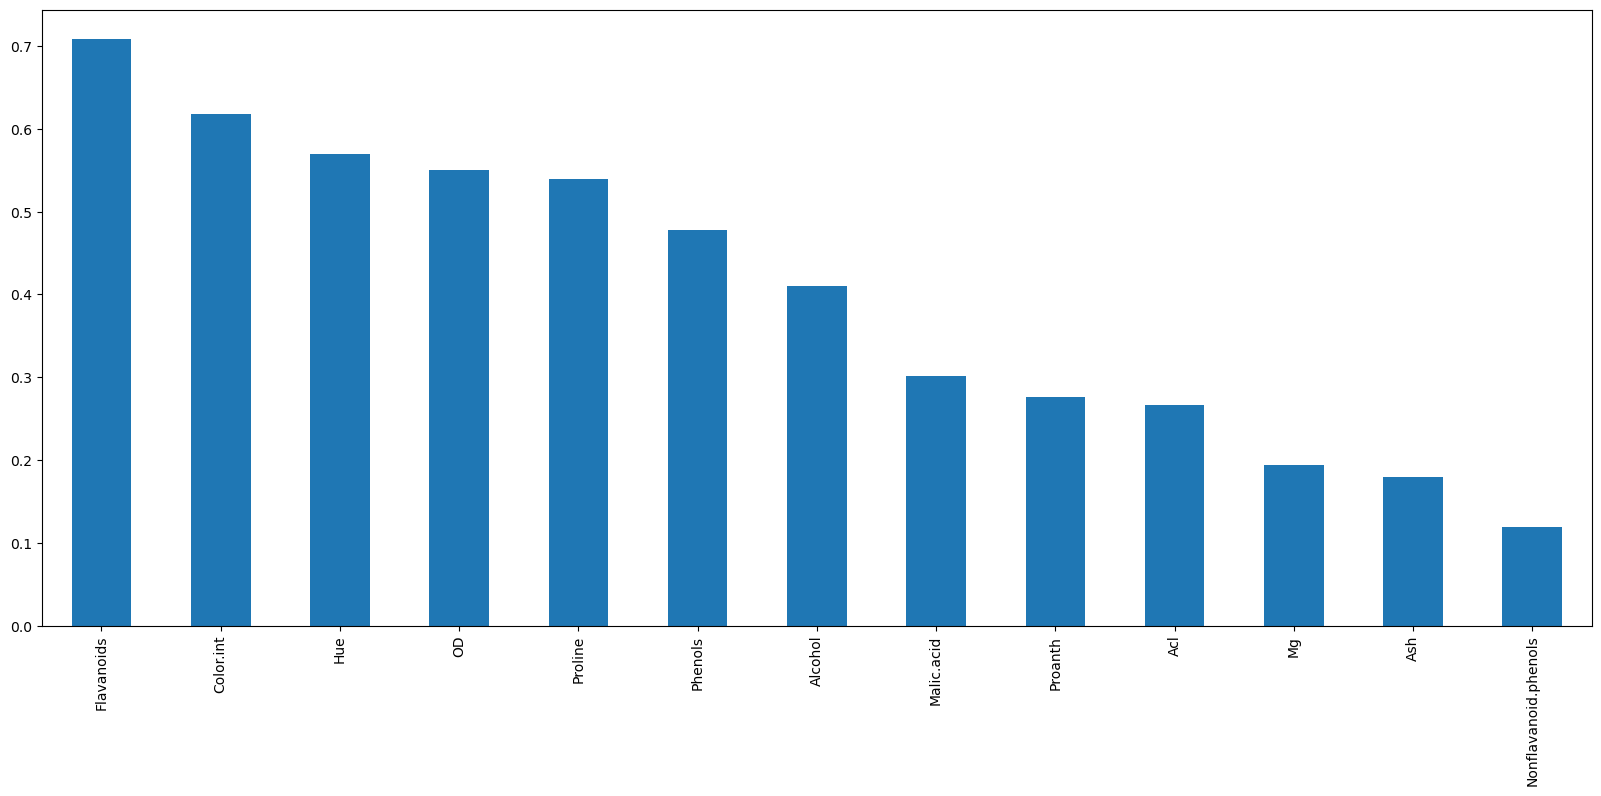

In [33]:
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20,8))

In [35]:
from sklearn.feature_selection import SelectKBest
sel_five_cols = SelectKBest(mutual_info_classif, k=5)
sel_five_cols.fit(X_train.fillna(0), y_train) #null values varsa, ama burada yok
X_train.columns[sel_five_cols.get_support()]

Index(['Flavanoids', 'Color.int', 'Hue', 'OD', 'Proline'], dtype='object')

Difference Between Information Gain And Mutual Information
I(X ; Y) = H(X) – H(X | Y) and IG(S, a) = H(S) – H(S | a)

As such, mutual information is sometimes used as a synonym for information gain. Technically, they calculate the same quantity if applied to the same data.


Comparison of F-test and mutual information

F-test captures only linear dependency. Mutual information can capture any kind of dependency between variables. 